1.0


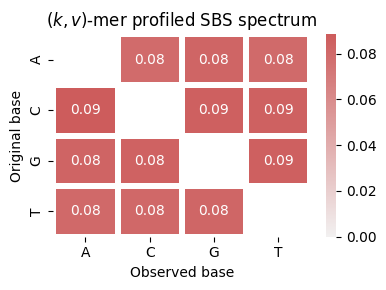

In [5]:
import pandas as pd
import numpy as np

kvmer_spectrum = "../../output/error_spectrum/kvmer_output.csv"
minimap_result = "../../output/error_spectrum/Ecoli_K12_MG1655_depth_128_id_96.summary_identity_stats.csv"

kvmer_df = pd.read_csv(kvmer_spectrum)
minimap_df = pd.read_csv(minimap_result)

#cols = ["A", "C", "G", "T", "-"]
cols = ["A", "C", "G", "T"]
bases = ["A", "C", "G", "T"]



spectrum_df = pd.read_csv(kvmer_spectrum)

spectrum_matrix = np.zeros((4, 4))
for from_base in cols:
    for to_base in cols:
        for prev_base in bases:
            for next_base in bases:
                if from_base == to_base:
                    continue
                key = f"{prev_base}[{from_base}>{to_base}]{next_base}"
                spectrum_matrix[cols.index(from_base), cols.index(to_base)] += spectrum_df[key].item()

# Normalize
spectrum_matrix /= spectrum_matrix.sum()
print(spectrum_matrix.sum())


def get_kvmer_error_type_spectrum(df):
    # insertion, deletion, substitution
    spectrum = {"Insertion": 0, "Deletion": 0, "Substitution": 0}
    for col in df.columns:
        if ">-" in col:
            spectrum["Deletion"] += df[col].item()
        elif "->" in col:
            spectrum["Insertion"] += df[col].item()
        elif ">" in col:
            spectrum["Substitution"] += df[col].item()
    
    return spectrum

def get_minimap_error_type_spectrum(df):
    spectrum = {"Insertion": 0, "Deletion": 0, "Substitution": 0}
    spectrum["Insertion"] += df["non_hp_ins_per_kbp"].sum()
    spectrum["Insertion"] += df["hp_ins_per_kbp"].sum()
    spectrum["Deletion"] += df["non_hp_del_per_kbp"].sum()
    spectrum["Deletion"] += df["hp_del_per_kbp"].sum()
    spectrum["Substitution"] += df["mismatches_per_kbp"].sum()
    return spectrum


kvmer_error_type_spectrum = get_kvmer_error_type_spectrum(kvmer_df)
minimap_error_type_spectrum = get_minimap_error_type_spectrum(minimap_df)

# Plot the heatmap of sbs6 spectrum
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
mask_matrix = np.eye(4)
# also mask the diagonal
sns.heatmap(spectrum_matrix, annot=True, fmt=".2f", 
            xticklabels=["A", "C", "G", "T"], yticklabels=["A", "C", "G", "T"],
            linecolor="white", linewidth=3,
            vmin=0,
            mask=mask_matrix, cmap=sns.light_palette("indianred", as_cmap=True))
plt.title("$(k,v)$-mer profiled SBS spectrum")
plt.ylabel("Original base")
plt.xlabel("Observed base")
plt.tight_layout()
plt.savefig("../../figures/simulated_data_sbs_spectrum.pdf")



    

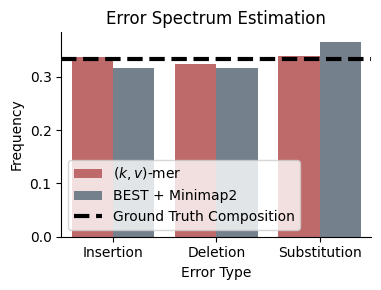

In [6]:
# Plot error type spectra for both methods as bar plots

# Normalize both spectra
total_kvmer_errors = sum(kvmer_error_type_spectrum.values())
kvmer_error_type_spectrum_normalized = {}
for et in kvmer_error_type_spectrum:
    kvmer_error_type_spectrum_normalized[et] = kvmer_error_type_spectrum[et] / total_kvmer_errors

total_minimap_errors = sum(minimap_error_type_spectrum.values())
minimap_error_type_spectrum_normalized = {}
for et in minimap_error_type_spectrum:
    minimap_error_type_spectrum_normalized[et] = minimap_error_type_spectrum[et] / total_minimap_errors

# into a df
method = []
error_type = []
frequency = []
for et in kvmer_error_type_spectrum_normalized:
    method.append("$(k,v)$-mer")
    error_type.append(et)
    frequency.append(kvmer_error_type_spectrum_normalized[et])


for et in minimap_error_type_spectrum_normalized:
    method.append("BEST + Minimap2")
    error_type.append(et)
    frequency.append(minimap_error_type_spectrum_normalized[et])

spectrum_df = {"Method": method, "Error Type": error_type, "Frequency": frequency}
spectrum_df = pd.DataFrame(spectrum_df)

plt.figure(figsize=(4, 3))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
sns.barplot(data=spectrum_df, x="Error Type", y="Frequency", hue="Method",
            palette=["indianred", 'slategray'])
plt.axhline(1/3, color="black", linewidth=3, linestyle="--", label="Ground Truth Composition")
plt.legend()
plt.title("Error Spectrum Estimation")
plt.tight_layout()
plt.savefig("../../figures/simulated_data_error_type_spectrum.pdf")






1.0
1.0
0.9999999999999999
1.0


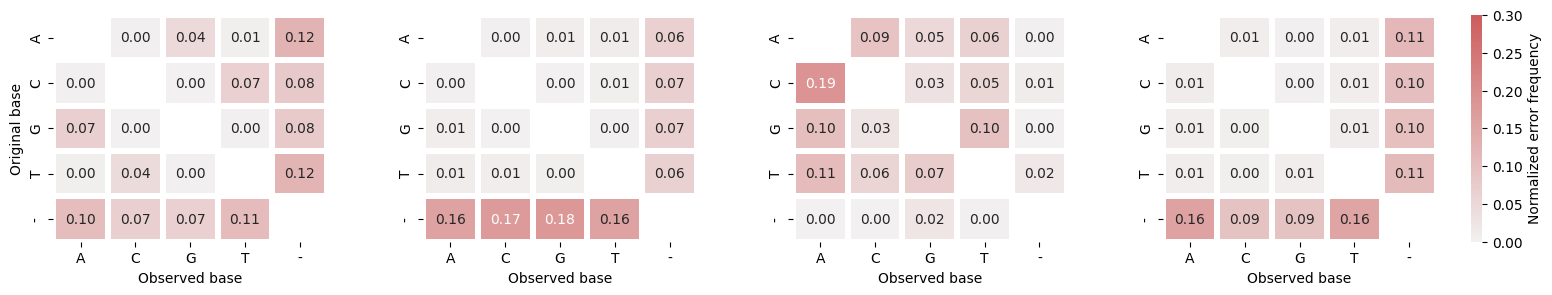

In [3]:
import matplotlib as mpl

kvmer_spectra = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
]

vmin = 0
vmax = 0.3
cmap = sns.light_palette("indianred", as_cmap=True)

cols = ["A", "C", "G", "T", "-"]
bases = ["A", "C", "G", "T"]

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3))

for i in range(len(kvmer_spectra)):
    spectrum_df = pd.read_csv(kvmer_spectra[i])

    spectrum_matrix = np.zeros((5, 5))
    for from_base in cols:
        for to_base in cols:
            for prev_base in bases:
                for next_base in bases:
                    if from_base == to_base:
                        continue
                    key = f"{prev_base}[{from_base}>{to_base}]{next_base}"
                    spectrum_matrix[cols.index(from_base), cols.index(to_base)] += spectrum_df[key].item()
    
    # Normalize
    spectrum_matrix /= spectrum_matrix.sum()
    print(spectrum_matrix.sum())

    # Plot the headmap
    ax = axes[i]
    mask_matrix = np.eye(5, dtype=bool)
    sns.heatmap(spectrum_matrix, annot=True, fmt=".2f", 
                xticklabels=cols, yticklabels=cols,
                vmin=0, vmax=0.3,
                cbar=False, mask=mask_matrix,
                linewidths=3, linecolor='white',
                cmap=cmap, ax=ax)
    #ax.set_title(labels[i])
    if i == 0:
        ax.set_ylabel("Original base")
    ax.set_xlabel("Observed base")
plt.tight_layout()

    
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.04,   # width of colorbar
    pad=0.02         # gap between plots and colorbar
)
cbar.set_label("Normalized error frequency")
cbar.outline.set_visible(False)
#cbar.set_label("Normalized mutation frequency")# Adjust layout to make space for the color bar
plt.subplots_adjust(wspace=0.35, right=0.93)
plt.savefig("../../figures/real_data_sbs_spectra.svg")


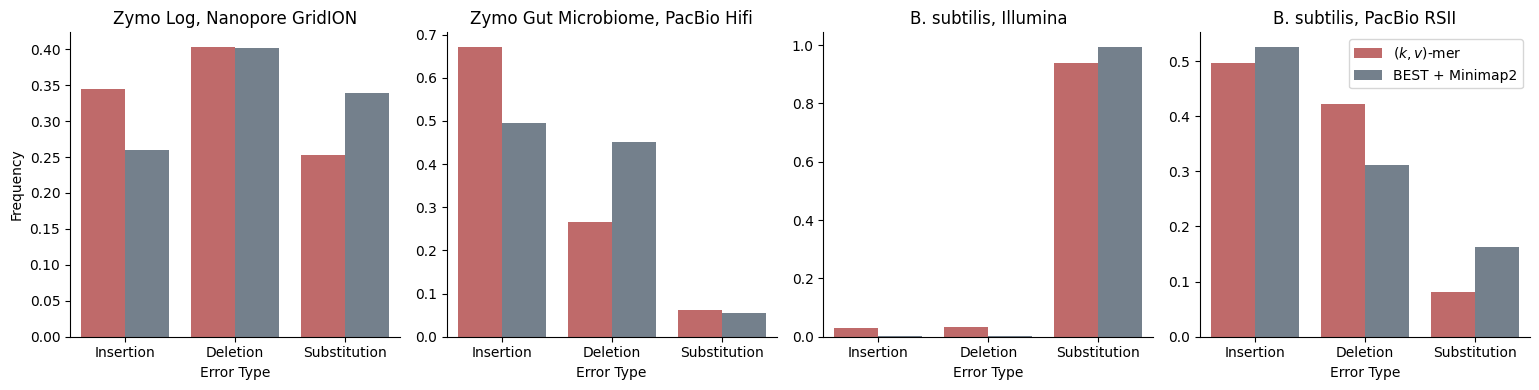

In [4]:
minimap2_results = [
    "../../output/zymo/ERR3152366.summary_identity_stats.csv",
    "../../output/zymo/SRR13128014.summary_identity_stats.csv",
    "../../output/zymo/ERR2935851_ref.summary_identity_stats.csv",
    "../../output/zymo/SRR7498042_ref.summary_identity_stats.csv",
]

# Plot insertion, deletion, substitution spectra for both methods as bar plots
method = []
error_type = []
frequency = []
dataset = []

for i in range(len(kvmer_spectra)):
    kvmer_df = pd.read_csv(kvmer_spectra[i])
    minimap_df = pd.read_csv(minimap2_results[i])

    kvmer_error_type_spectrum = get_kvmer_error_type_spectrum(kvmer_df)
    minimap_error_type_spectrum = get_minimap_error_type_spectrum(minimap_df)

    # Normalize both spectra
    total_kvmer_errors = sum(kvmer_error_type_spectrum.values())
    kvmer_error_type_spectrum_normalized = {}
    for et in kvmer_error_type_spectrum:
        kvmer_error_type_spectrum_normalized[et] = kvmer_error_type_spectrum[et] / total_kvmer_errors

    total_minimap_errors = sum(minimap_error_type_spectrum.values())
    minimap_error_type_spectrum_normalized = {}
    for et in minimap_error_type_spectrum:
        minimap_error_type_spectrum_normalized[et] = minimap_error_type_spectrum[et] / total_minimap_errors

    for et in kvmer_error_type_spectrum_normalized:
        method.append("$(k,v)$-mer")
        error_type.append(et)
        frequency.append(kvmer_error_type_spectrum_normalized[et])
        dataset.append(labels[i])


    for et in minimap_error_type_spectrum_normalized:
        method.append("BEST + Minimap2")
        error_type.append(et)
        frequency.append(minimap_error_type_spectrum_normalized[et])
        dataset.append(labels[i])

spectrum_df = {"Method": method, "Error Type": error_type, "Frequency": frequency, "Dataset": dataset}
spectrum_df = pd.DataFrame(spectrum_df)

# Plot 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4))
for i in range(len(labels)):
    ax = axes[i]
    subset_df = spectrum_df[spectrum_df["Dataset"] == labels[i]]
    sns.barplot(data=subset_df, x="Error Type", y="Frequency", hue="Method",
                palette=["indianred", 'slategray'], ax=ax)
    #ax.axhline(1/3, color="black", linewidth=3, linestyle="--", label="Ground Truth Composition")
    if i == 0:
        ax.set_ylabel("Frequency")
    else:
        ax.set_ylabel("")
    ax.set_title(labels[i])
    if i == 3:
        ax.legend()
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig("../../figures/spectra_vs_minimap.pdf")

In [18]:
spectrum_matrix.sum()

1.0

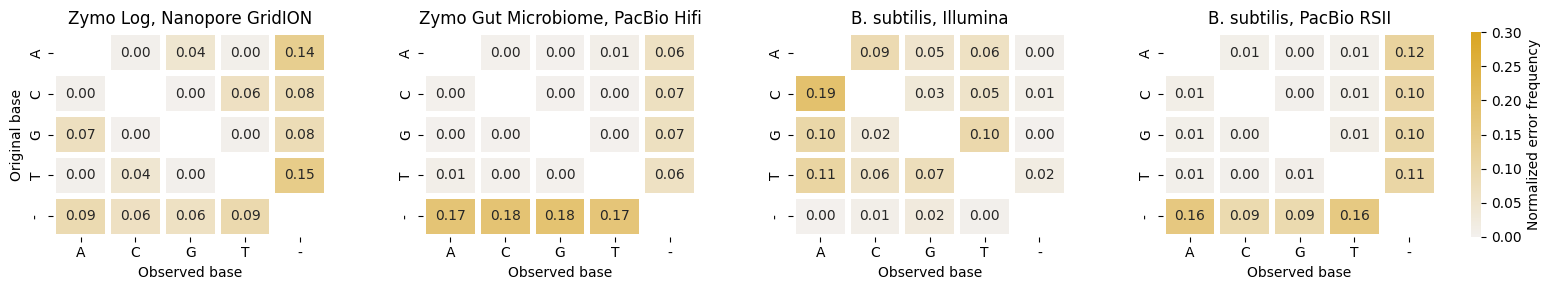

In [7]:
import matplotlib as mpl

kvmer_spectra = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref.csv",
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
]

vmin = 0
vmax = 0.3
cmap = sns.light_palette("goldenrod", as_cmap=True)

cols = ["A", "C", "G", "T", "-"]
bases = ["A", "C", "G", "T"]

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3))

for i in range(len(kvmer_spectra)):
    spectrum_df = pd.read_csv(kvmer_spectra[i])

    spectrum_matrix = np.zeros((5, 5))
    for from_base in cols:
        for to_base in cols:
            for prev_base in bases:
                for next_base in bases:
                    if from_base == to_base:
                        continue
                    key = f"{prev_base}[{from_base}>{to_base}]{next_base}"
                    spectrum_matrix[cols.index(from_base), cols.index(to_base)] += spectrum_df[key].item()
    
    # Normalize
    spectrum_matrix /= spectrum_matrix.sum()

    # Plot the headmap
    ax = axes[i]
    mask_matrix = np.eye(5, dtype=bool)
    sns.heatmap(spectrum_matrix, annot=True, fmt=".2f", 
                xticklabels=cols, yticklabels=cols,
                vmin=0, vmax=0.3,
                cbar=False, mask=mask_matrix,
                linewidths=3, linecolor='white',
                cmap=cmap, ax=ax)
    ax.set_title(labels[i])
    if i == 0:
        ax.set_ylabel("Original base")
    ax.set_xlabel("Observed base")
plt.tight_layout()

    
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.04,   # width of colorbar
    pad=0.02         # gap between plots and colorbar
)
cbar.set_label("Normalized error frequency")
cbar.outline.set_visible(False)
#cbar.set_label("Normalized mutation frequency")# Adjust layout to make space for the color bar
plt.subplots_adjust(wspace=0.35, right=0.93)
plt.savefig("../../figures/real_data_sbs_spectra_ref.pdf")


1.0
1.0
1.0


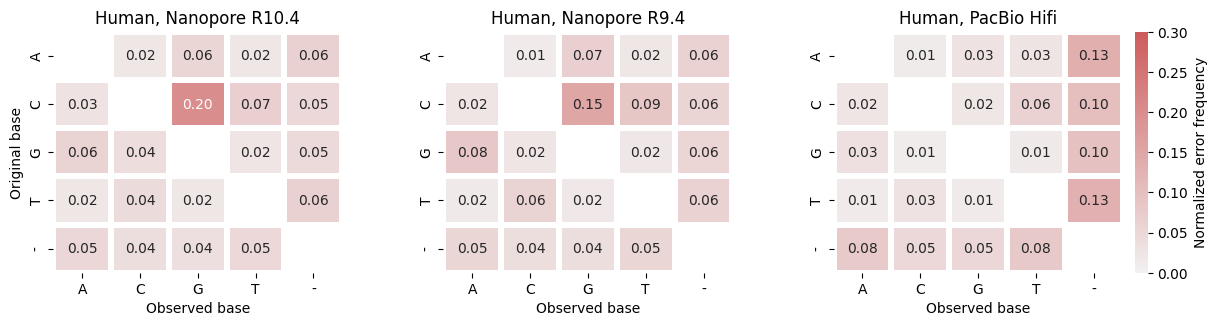

In [8]:
import matplotlib as mpl

kvmer_spectra = [
    "../../output/human/HG002_bi_kvmer.csv",
    "../../output/human/HG002_R941_bi_kvmer.csv",
    "../../output/human/HG002_hifi_bi_kvmer.csv",
]

labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

vmin = 0
vmax = 0.3
cmap = sns.light_palette("indianred", as_cmap=True)

cols = ["A", "C", "G", "T", "-"]
bases = ["A", "C", "G", "T"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
plt.tight_layout()
for i in range(len(kvmer_spectra)):
    spectrum_df = pd.read_csv(kvmer_spectra[i])

    spectrum_matrix = np.zeros((5, 5))
    for from_base in cols:
        for to_base in cols:
            for prev_base in bases:
                for next_base in bases:
                    if from_base == to_base:
                        continue
                    key = f"{prev_base}[{from_base}>{to_base}]{next_base}"
                    spectrum_matrix[cols.index(from_base), cols.index(to_base)] += spectrum_df[key].item()
    
    # Normalize
    spectrum_matrix /= spectrum_matrix.sum()
    print(spectrum_matrix.sum())

    # Plot the headmap
    ax = axes[i]
    mask_matrix = np.eye(5, dtype=bool)
    sns.heatmap(spectrum_matrix, annot=True, fmt=".2f", 
                xticklabels=cols, yticklabels=cols,
                vmin=0, vmax=0.3,
                cbar=False, mask=mask_matrix,
                linewidths=3, linecolor='white',
                cmap=cmap, ax=ax)
    ax.set_title(labels[i])
    if i == 0:
        ax.set_ylabel("Original base")
    ax.set_xlabel("Observed base")


    
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.04,   # width of colorbar
    pad=0.02         # gap between plots and colorbar
)
cbar.set_label("Normalized error frequency")
cbar.outline.set_visible(False)
#plt.tight_layout()
#cbar.set_label("Normalized mutation frequency")# Adjust layout to make space for the color bar
plt.subplots_adjust(wspace=0.35, right=0.93)
plt.savefig("../../figures/human_sbs_spectra.pdf")
